# Home Credit Default Risk — Exploratory Data Analysis

**Dataset:** `data/application_train.csv`  
**Tools:** pandas, matplotlib, seaborn

This notebook covers dataset overview, missing values, target distribution, income & credit analysis, correlations, default comparisons, and business insights.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOK_DIR))

from src.data.loader import load_application_train
from eda import (
    OUTPUT_DIR,
    business_insights,
    correlation_heatmap,
    credit_amount_analysis,
    dataset_overview,
    default_comparison,
    income_analysis,
    missing_value_analysis,
    target_distribution,
)
from src.utils.helpers import ensure_dir, missing_summary

ensure_dir(OUTPUT_DIR)
sns.set_theme(style="whitegrid", font_scale=1.05)
%matplotlib inline

df = load_application_train()
df["TARGET"] = df["TARGET"].astype(int)
print(f"Loaded {len(df):,} applications × {df.shape[1]} features")
df.head()

2026-06-01 15:58:27,881 | INFO | src.data.loader | Loading application_train.csv


Loaded 307,511 applications × 122 features


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Dataset overview


1. DATASET OVERVIEW
  Applications (rows):          307,511
  Features (columns):               122
  Numeric features:                 106
  Categorical features:              16
  Memory usage:                   325.2 MB
  Duplicate SK_ID_CURR:               0


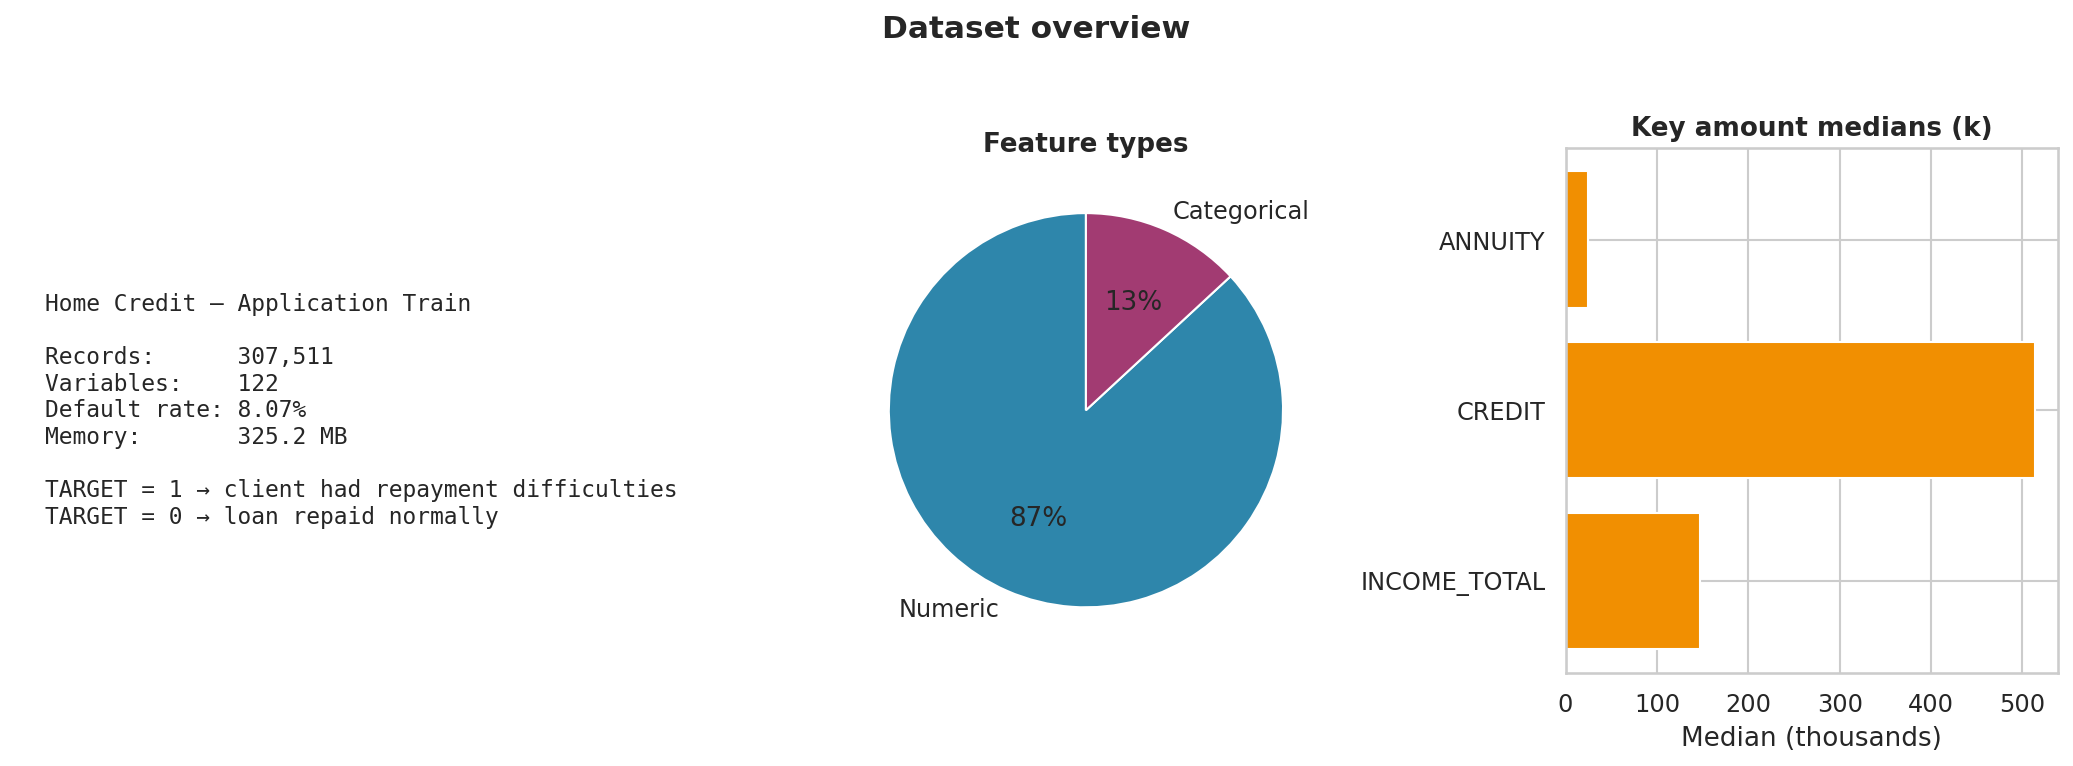

  Saved documents/eda/01_dataset_overview.png


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.00000,189145.500000,278202.00000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.00000,0.000000,0.00000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.00000,0.000000,0.00000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.00000,-19682.000000,-15750.00000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.00000,-2760.000000,-1213.00000,-289.000000,3.652430e+05



Dtypes: {dtype('float64'): 65, dtype('int64'): 41, <StringDtype(na_value=nan)>: 16}


In [2]:
overview = dataset_overview(df)
display(df.describe().T.head(12))
print(f"\nDtypes: {df.dtypes.value_counts().to_dict()}")

## 2. Missing value analysis


2. MISSING VALUE ANALYSIS
  Columns with any missing: 67 / 122
  Max missing %:            69.9%

  Top 10 columns by missing %:
                          missing    pct
COMMONAREA_MEDI            214865  69.87
COMMONAREA_MODE            214865  69.87
COMMONAREA_AVG             214865  69.87
NONLIVINGAPARTMENTS_MODE   213514  69.43
NONLIVINGAPARTMENTS_MEDI   213514  69.43
NONLIVINGAPARTMENTS_AVG    213514  69.43
FONDKAPREMONT_MODE         210295  68.39
LIVINGAPARTMENTS_AVG       210199  68.35
LIVINGAPARTMENTS_MEDI      210199  68.35
LIVINGAPARTMENTS_MODE      210199  68.35


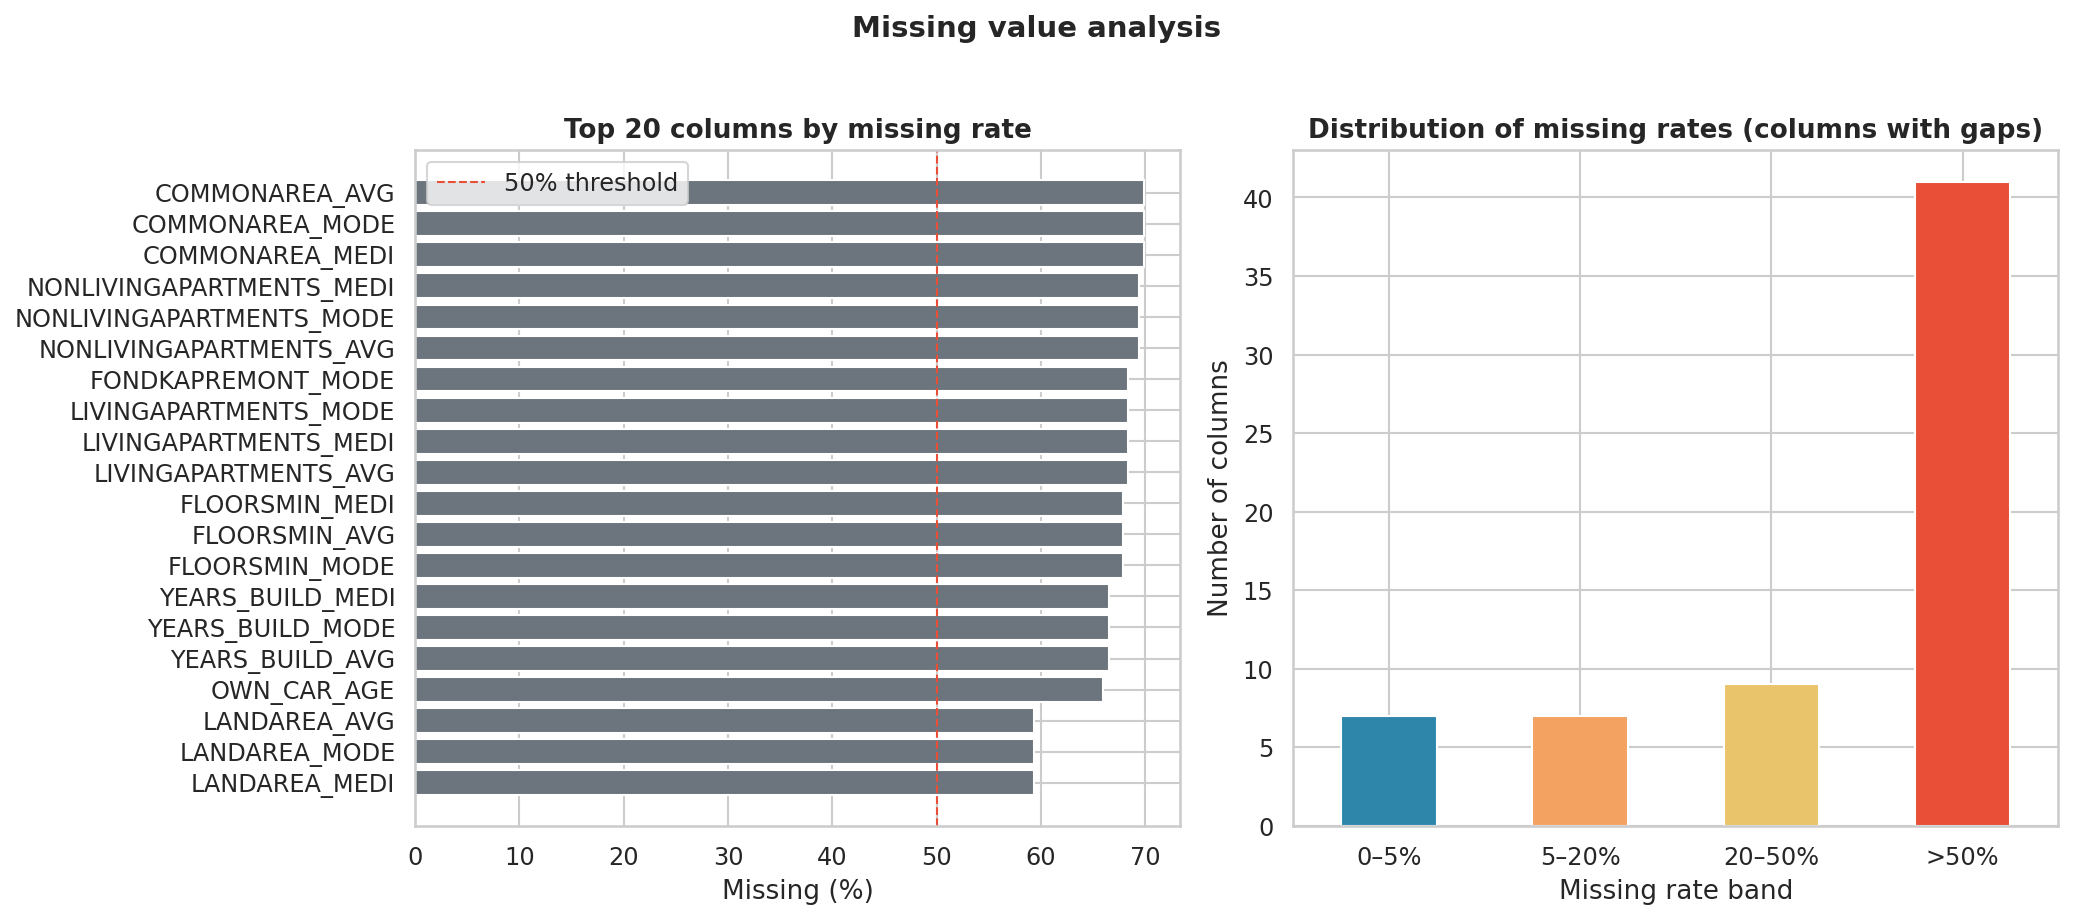

  Saved documents/eda/02_missing_values.png


,missing,pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [3]:
missing = missing_value_analysis(df)
missing.head(15)

## 3. Target distribution

`TARGET = 1` indicates the client had payment difficulties (default). The portfolio is **highly imbalanced**.


3. TARGET DISTRIBUTION
  Class 0 (no difficulty):     282,686  (91.93%)
  Class 1 (difficulties):       24,825  (8.07%)
  Imbalance ratio:          1 : 11.4


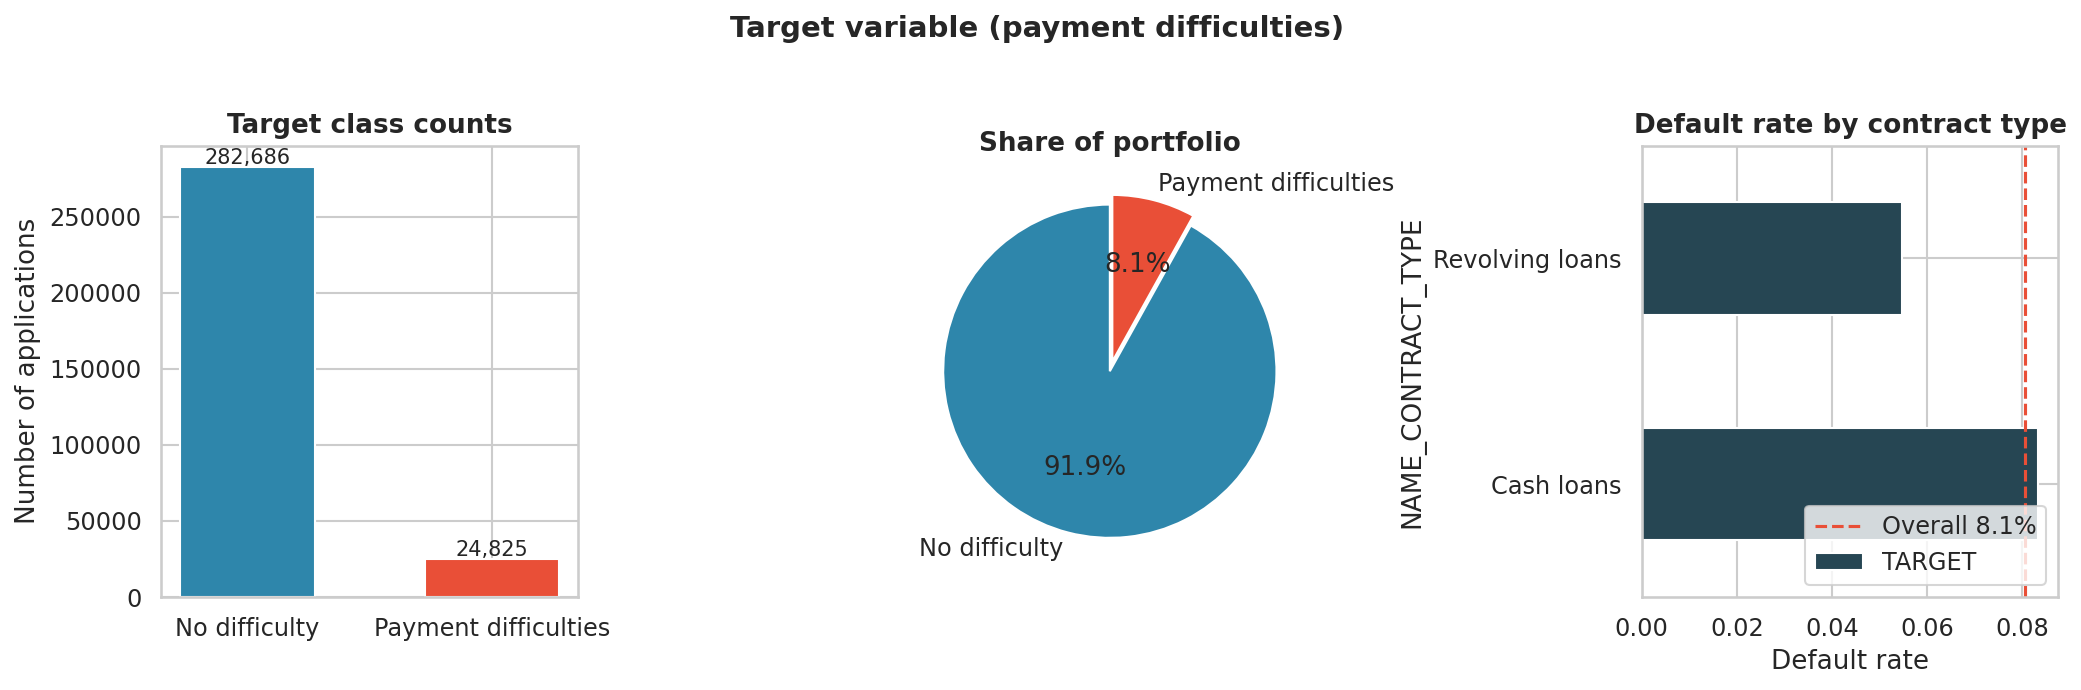

  Saved documents/eda/03_target_distribution.png


TARGET
No difficulty           0.919271
Payment difficulties    0.080729
Name: proportion, dtype: float64

In [4]:
target_distribution(df)
df["TARGET"].value_counts(normalize=True).rename(index={0: "No difficulty", 1: "Payment difficulties"})

## 4. Income analysis


4. INCOME ANALYSIS


  Median income (TARGET=0): $148,500
  Median income (TARGET=1): $135,000


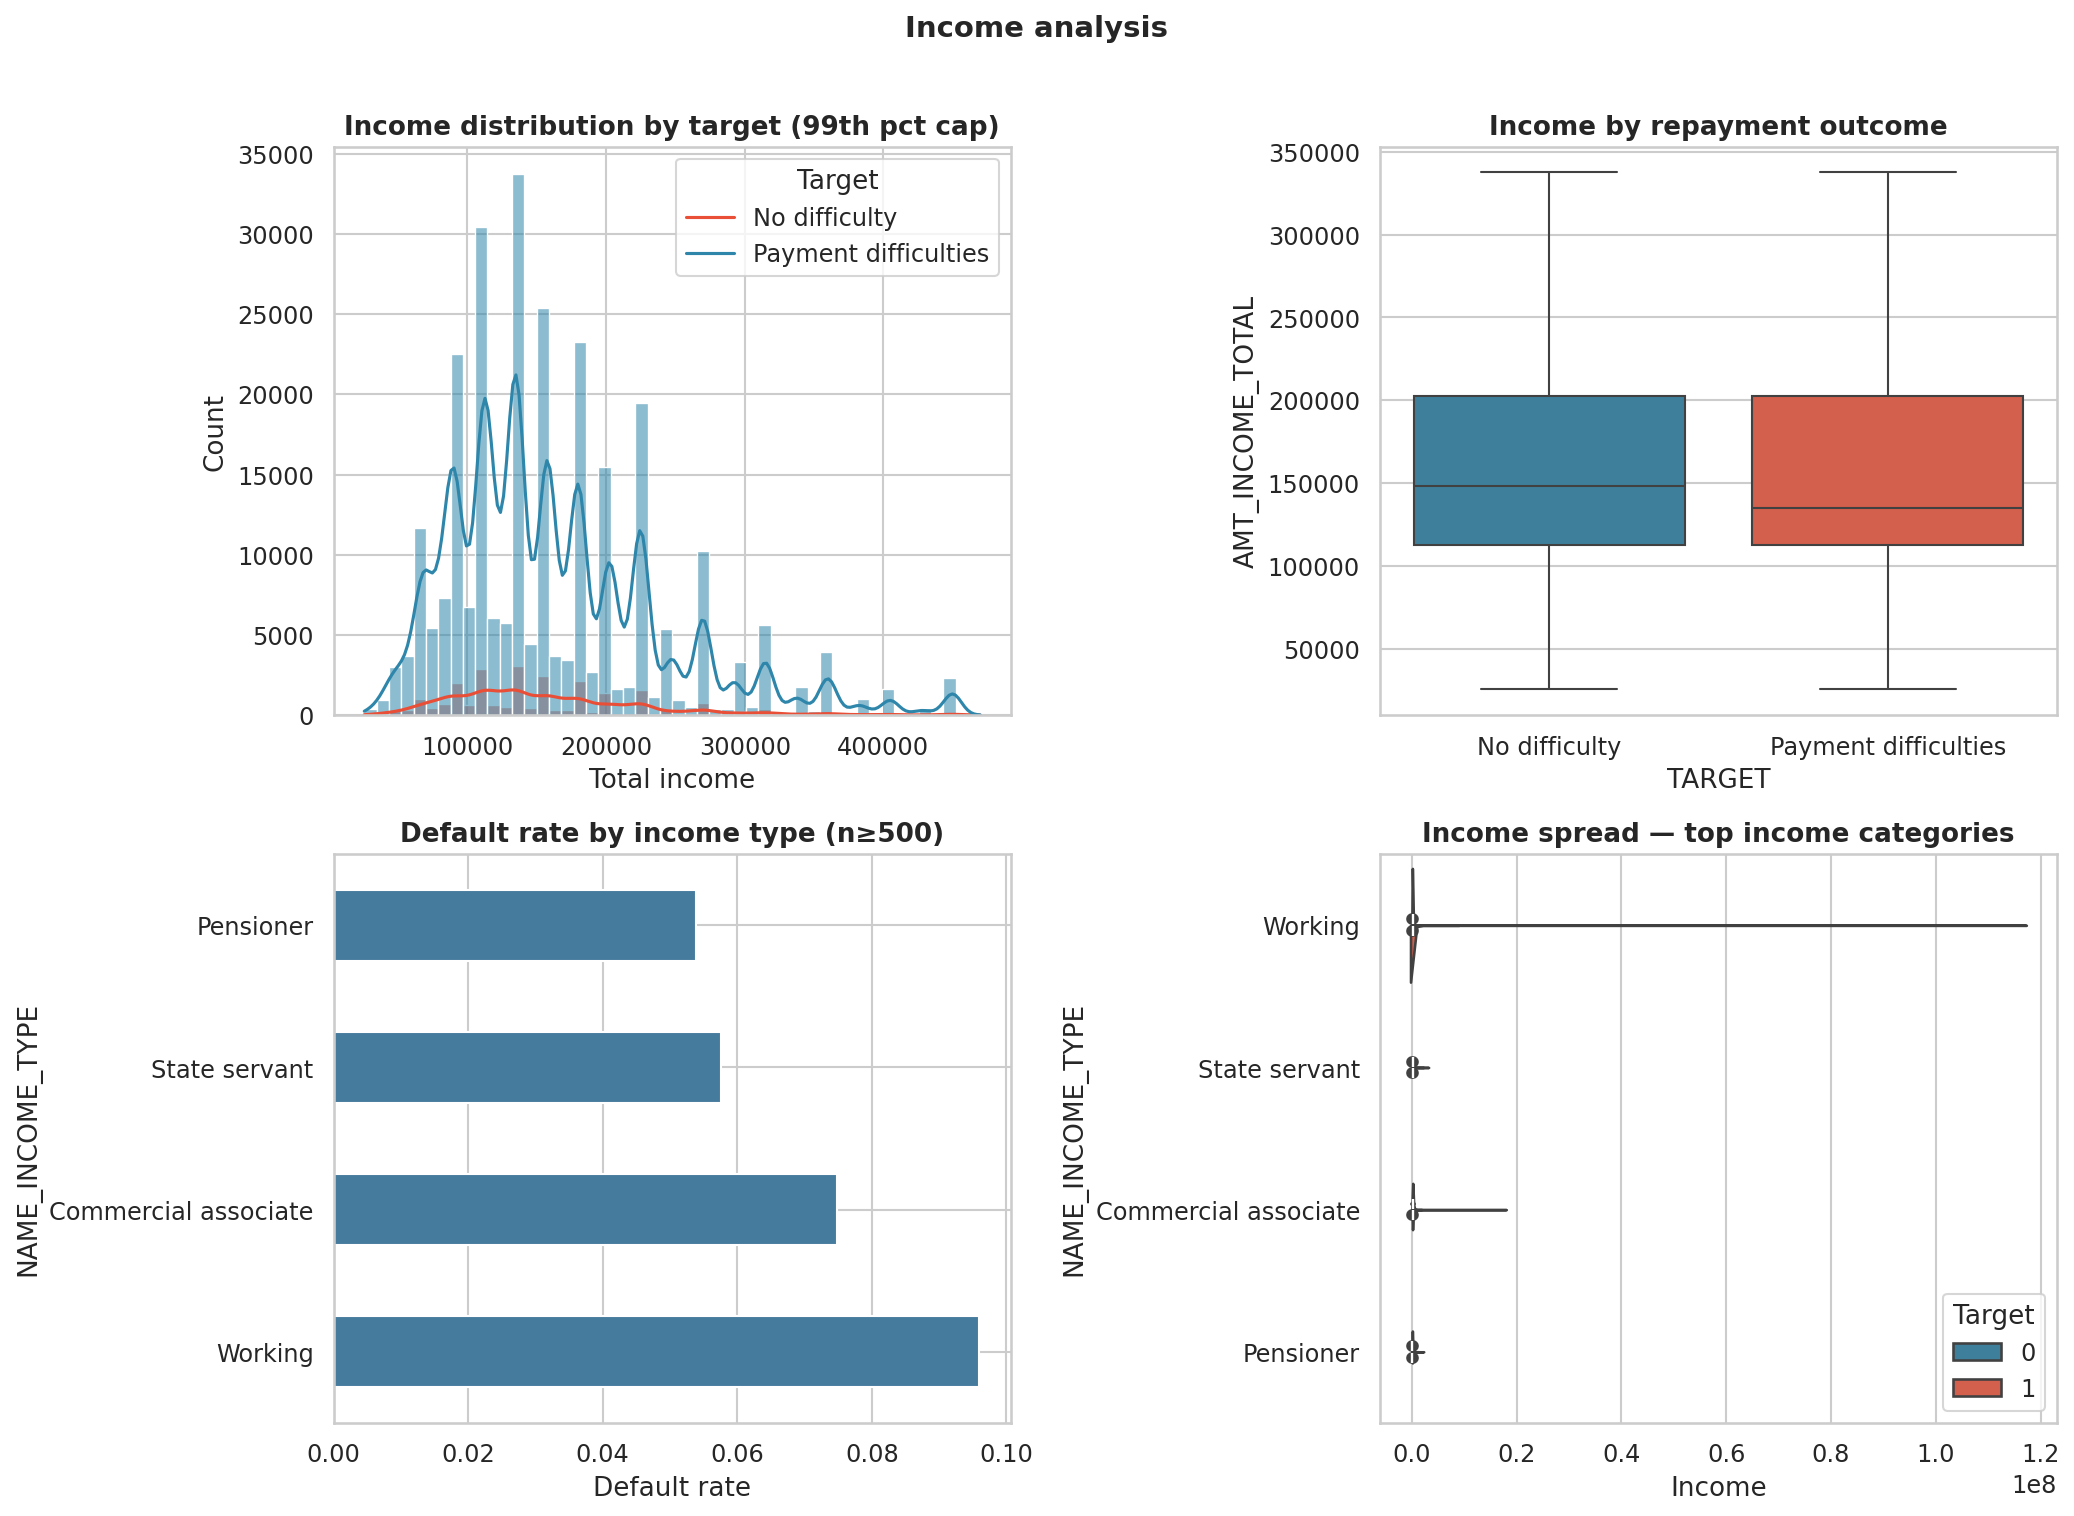

  Saved documents/eda/04_income_analysis.png


In [5]:
income_analysis(df)

## 5. Credit amount analysis


5. CREDIT AMOUNT ANALYSIS


  Median credit:              $513,531
  Median annuity:             $24,903
  Median credit/income ratio: 3.27


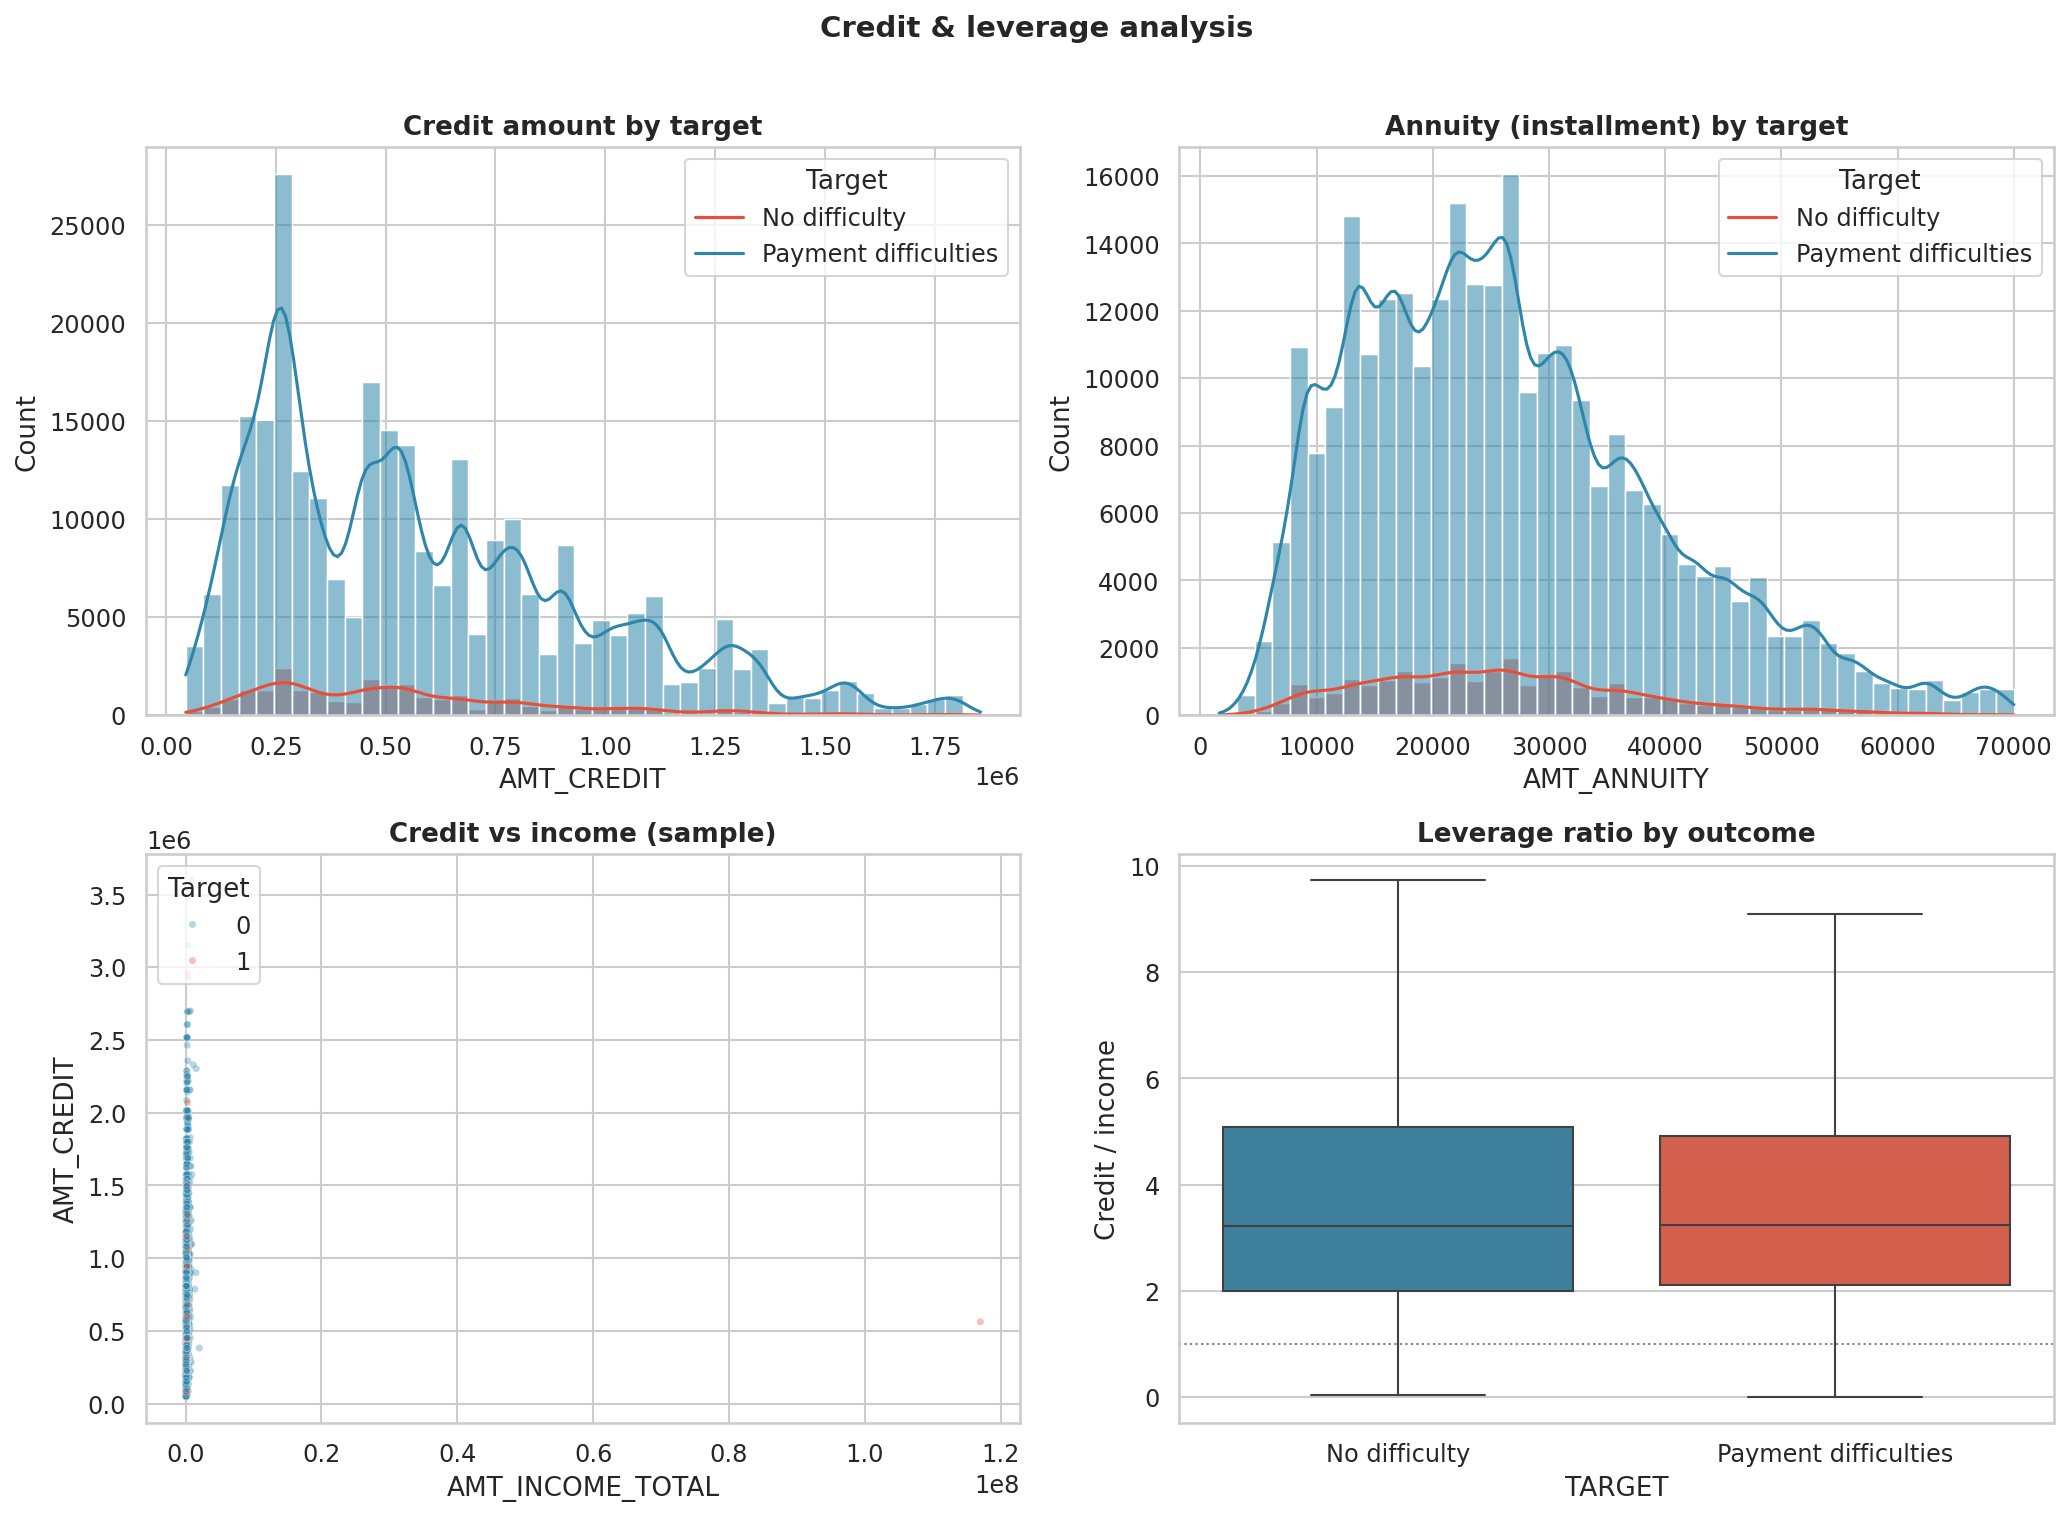

  Saved documents/eda/05_credit_analysis.png


In [6]:
credit_amount_analysis(df)

## 6. Correlation heatmap

Pearson correlations among key numeric variables. External source scores (`EXT_SOURCE_*`) typically show the strongest relationship with default.


6. CORRELATION HEATMAP


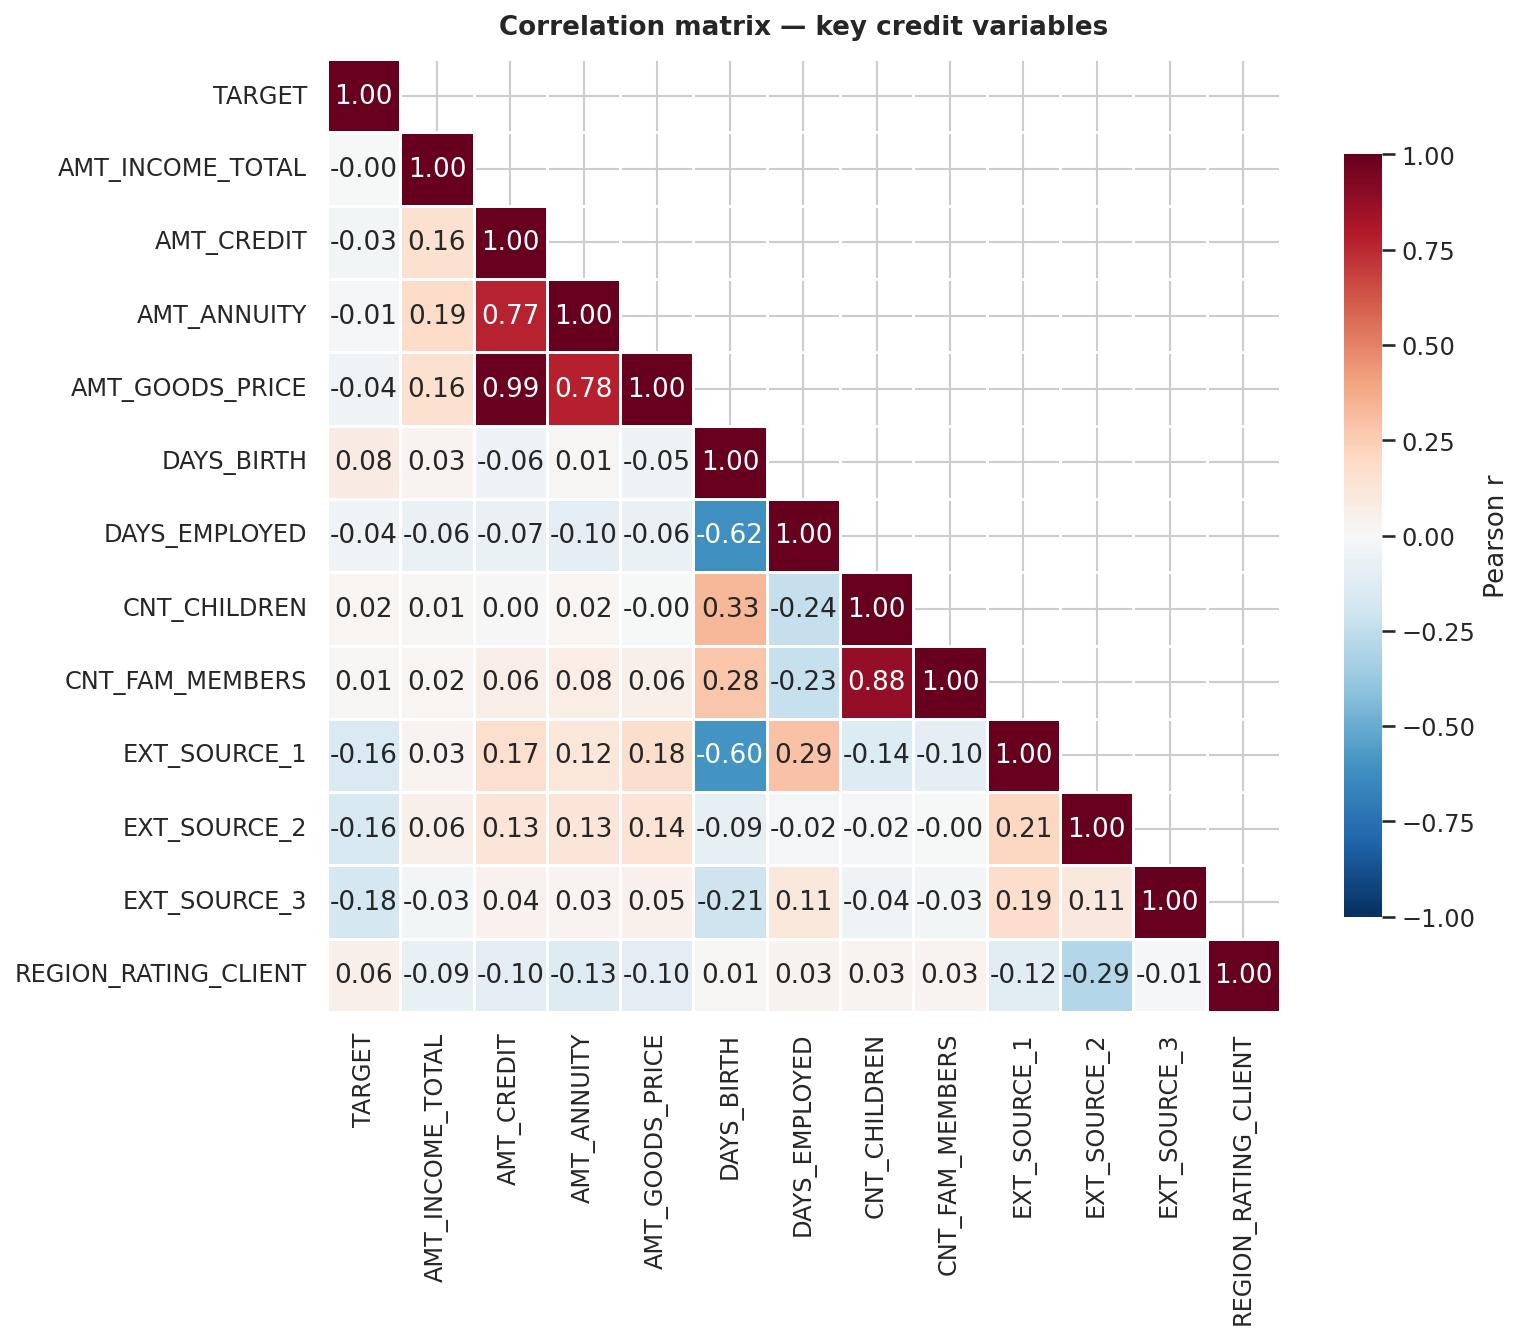

  Saved documents/eda/06_correlation_heatmap.png
  Strongest correlations with TARGET:
    EXT_SOURCE_3               r = -0.179
    EXT_SOURCE_2               r = -0.160
    EXT_SOURCE_1               r = -0.155
    DAYS_BIRTH                 r = +0.078
    REGION_RATING_CLIENT       r = +0.059


In [7]:
correlation_heatmap(df)

## 7. Default vs non-default comparison


7. DEFAULT VS NON-DEFAULT COMPARISON


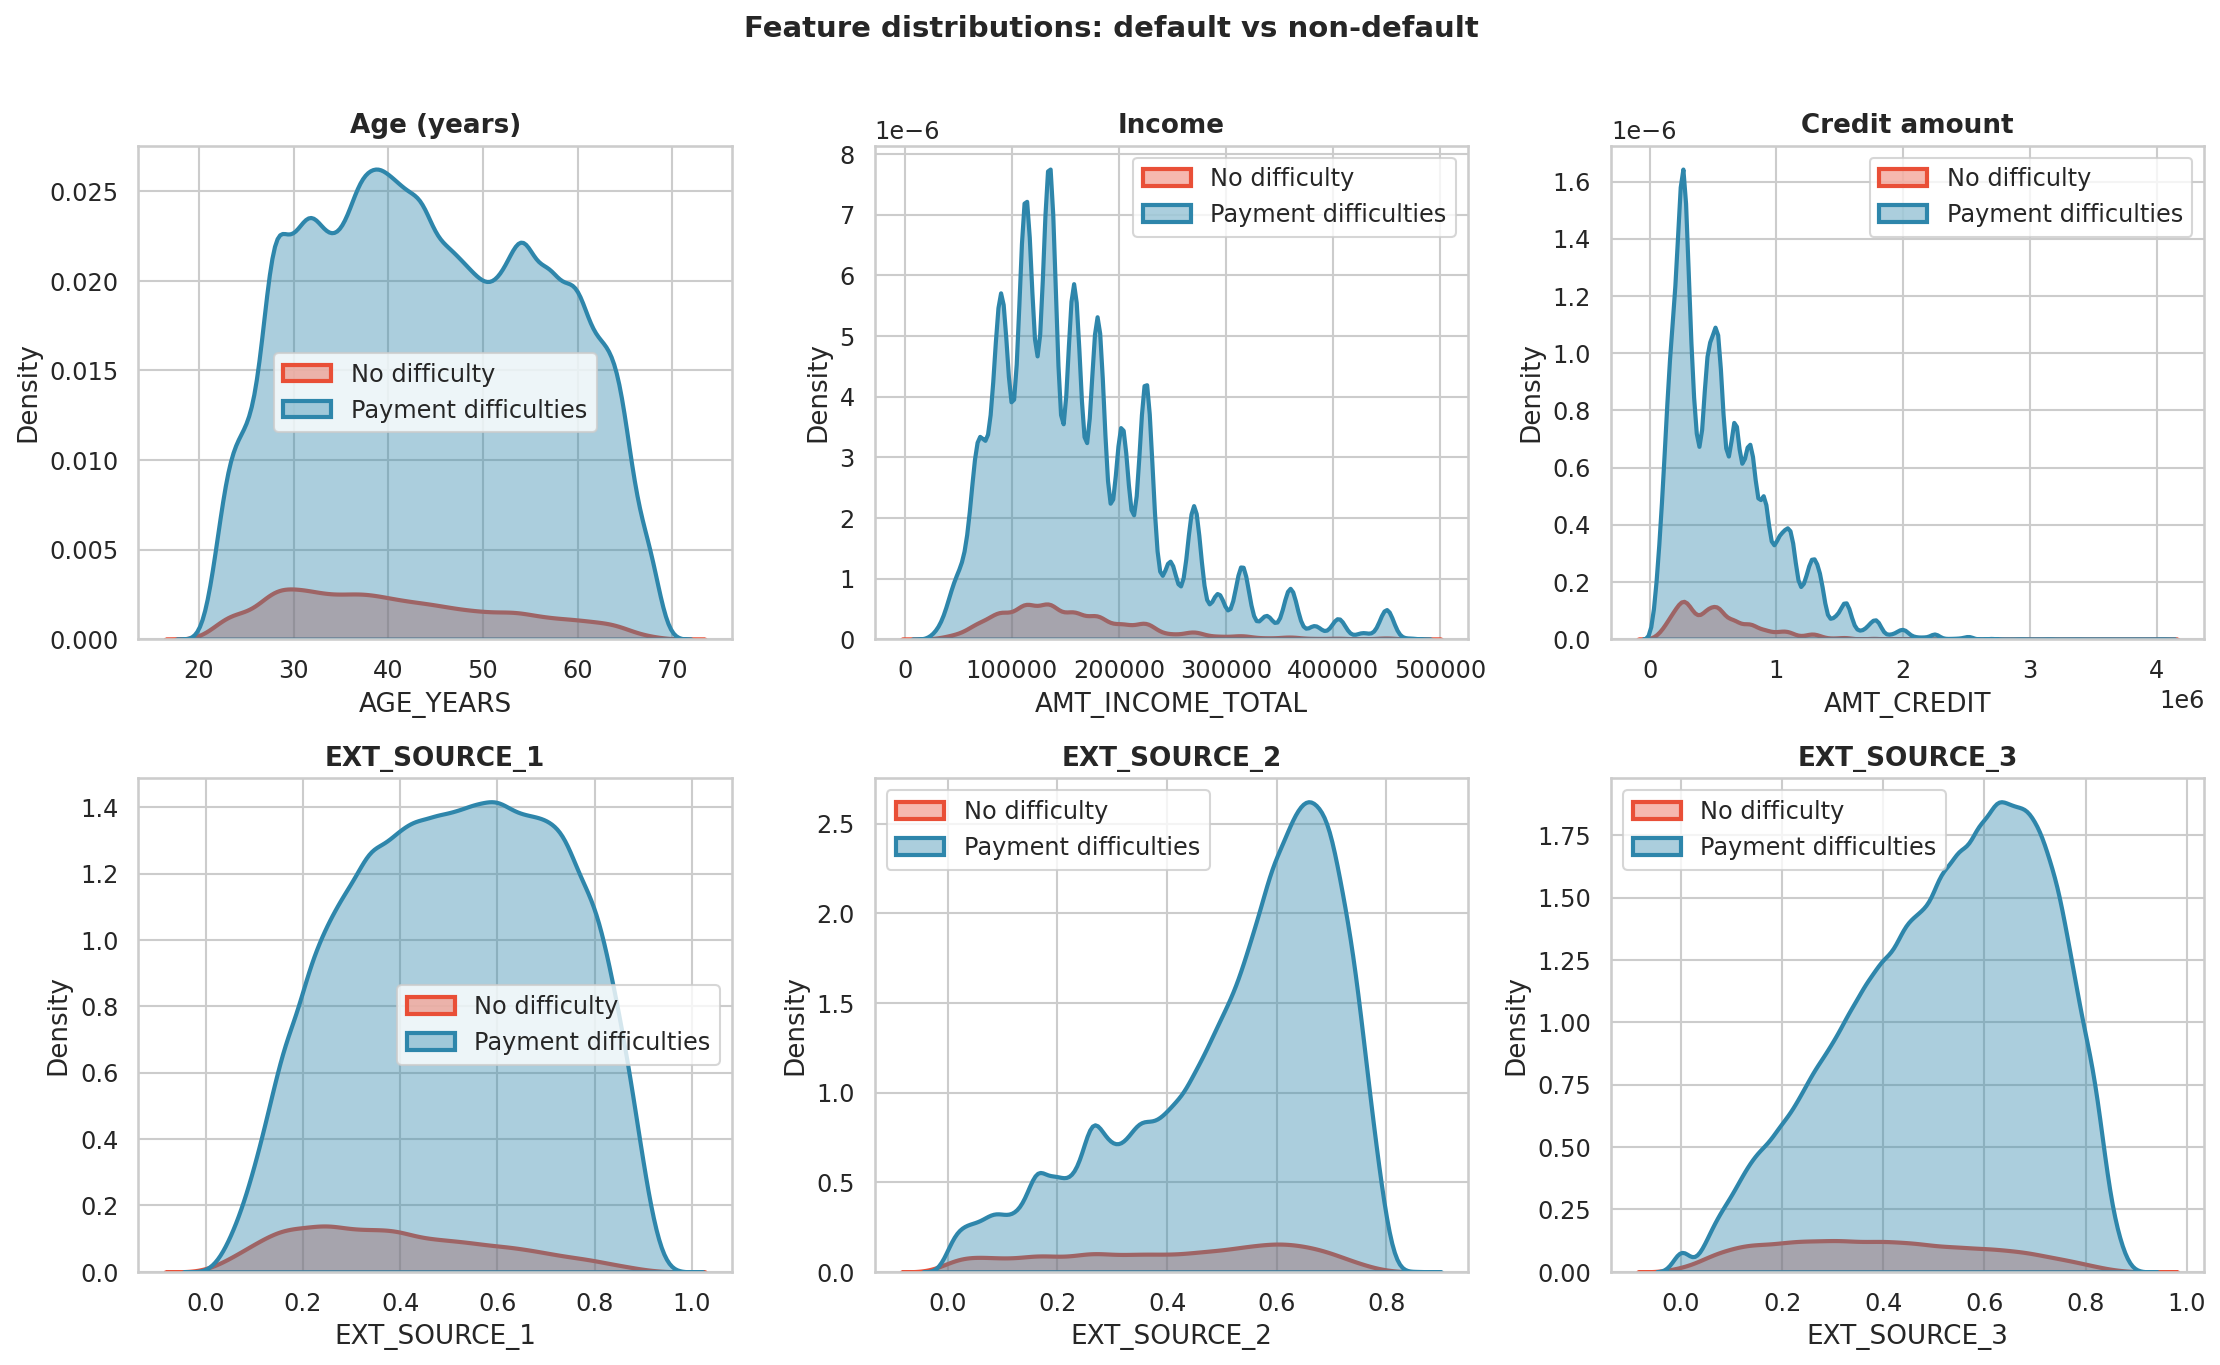

  Saved documents/eda/07_default_comparison.png


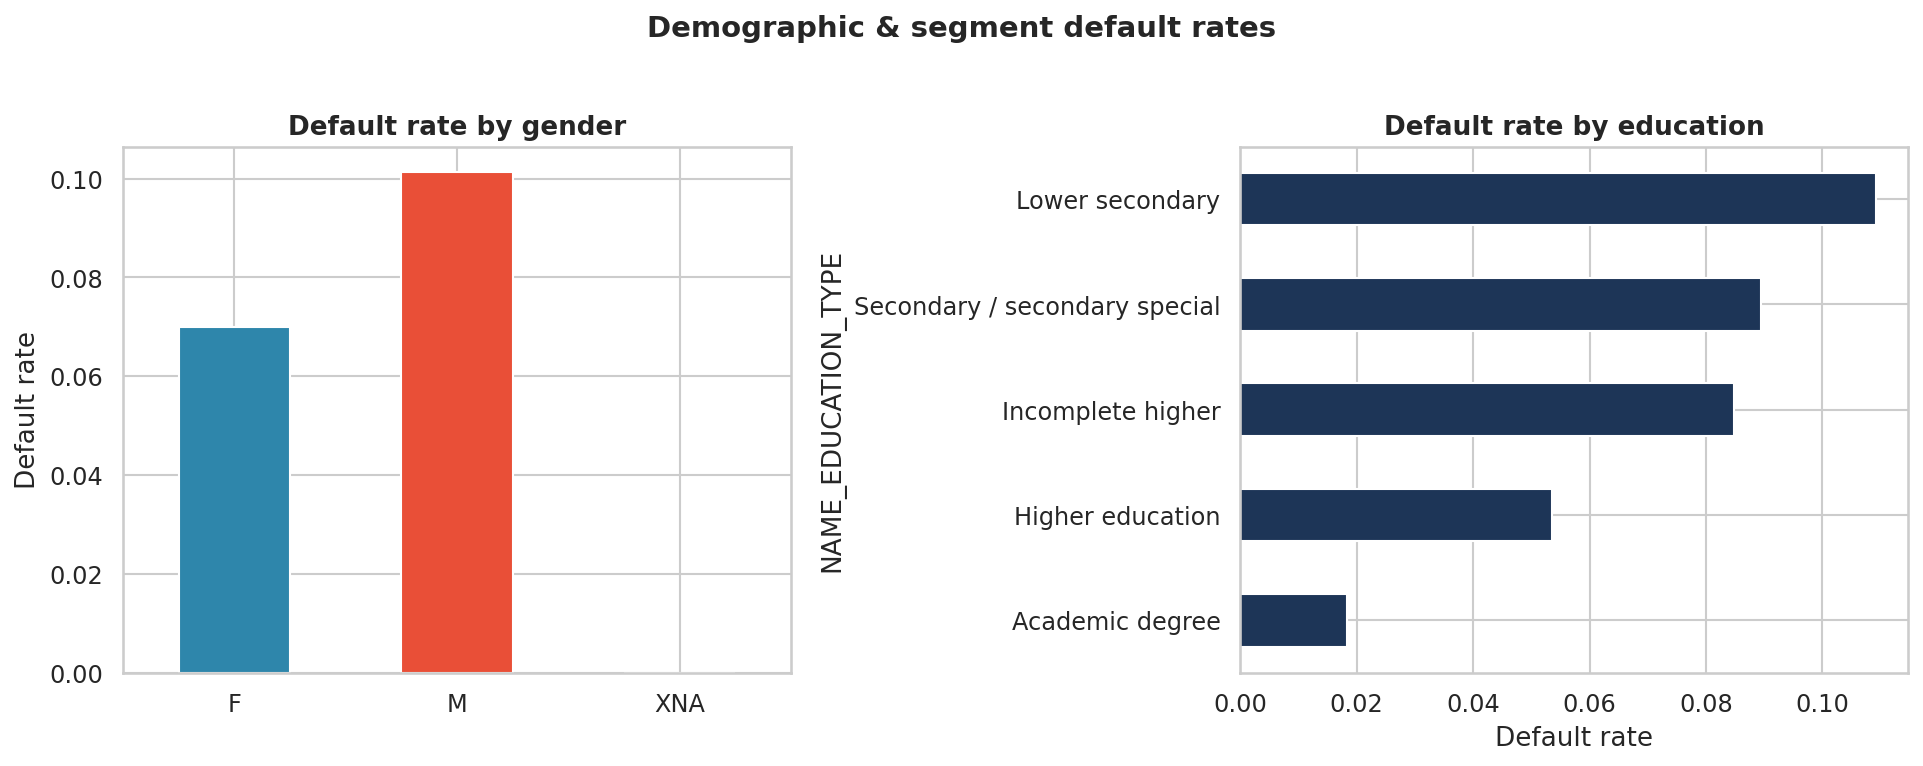

  Saved documents/eda/08_segment_comparison.png


In [8]:
default_comparison(df)

## 8. Business insights

Data-driven takeaways for risk, product, and policy teams (computed from this dataset).


8. BUSINESS INSIGHTS



  Insight 1:
  Portfolio default rate is 8.07% (~24,825 distressed loans of
  307,511), indicating strong class imbalance for modeling.

  Insight 2:
  External bureau scores are highly discriminative: bottom-quartile
  combined EXT_SOURCE clients default at 17.3% vs 2.7% in the top
  quartile — prioritize score completion and imputation in
  underwriting.

  Insight 3:
  Younger applicants (<35 years) default at 10.9% compared with 7.0%
  for older clients — age-adjusted pricing or limits may reduce
  losses.

  Insight 4:
  Credit-to-income ratio varies widely (median 3.3x): bottom-quartile
  leverage defaults at 7.5% vs 7.4% in the top quartile — combine
  leverage with bureau scores, not income alone.

  Insight 5:
  Cash loans default at 8.3% vs revolving loans at 5.5%; product-
  specific models and monitoring beat a single portfolio-wide
  scorecard.

  Insight 6:
  Clients flagged as unemployed (special DAYS_EMPLOYED code) show a
  default rate of 5.4% vs portfolio average 8.1

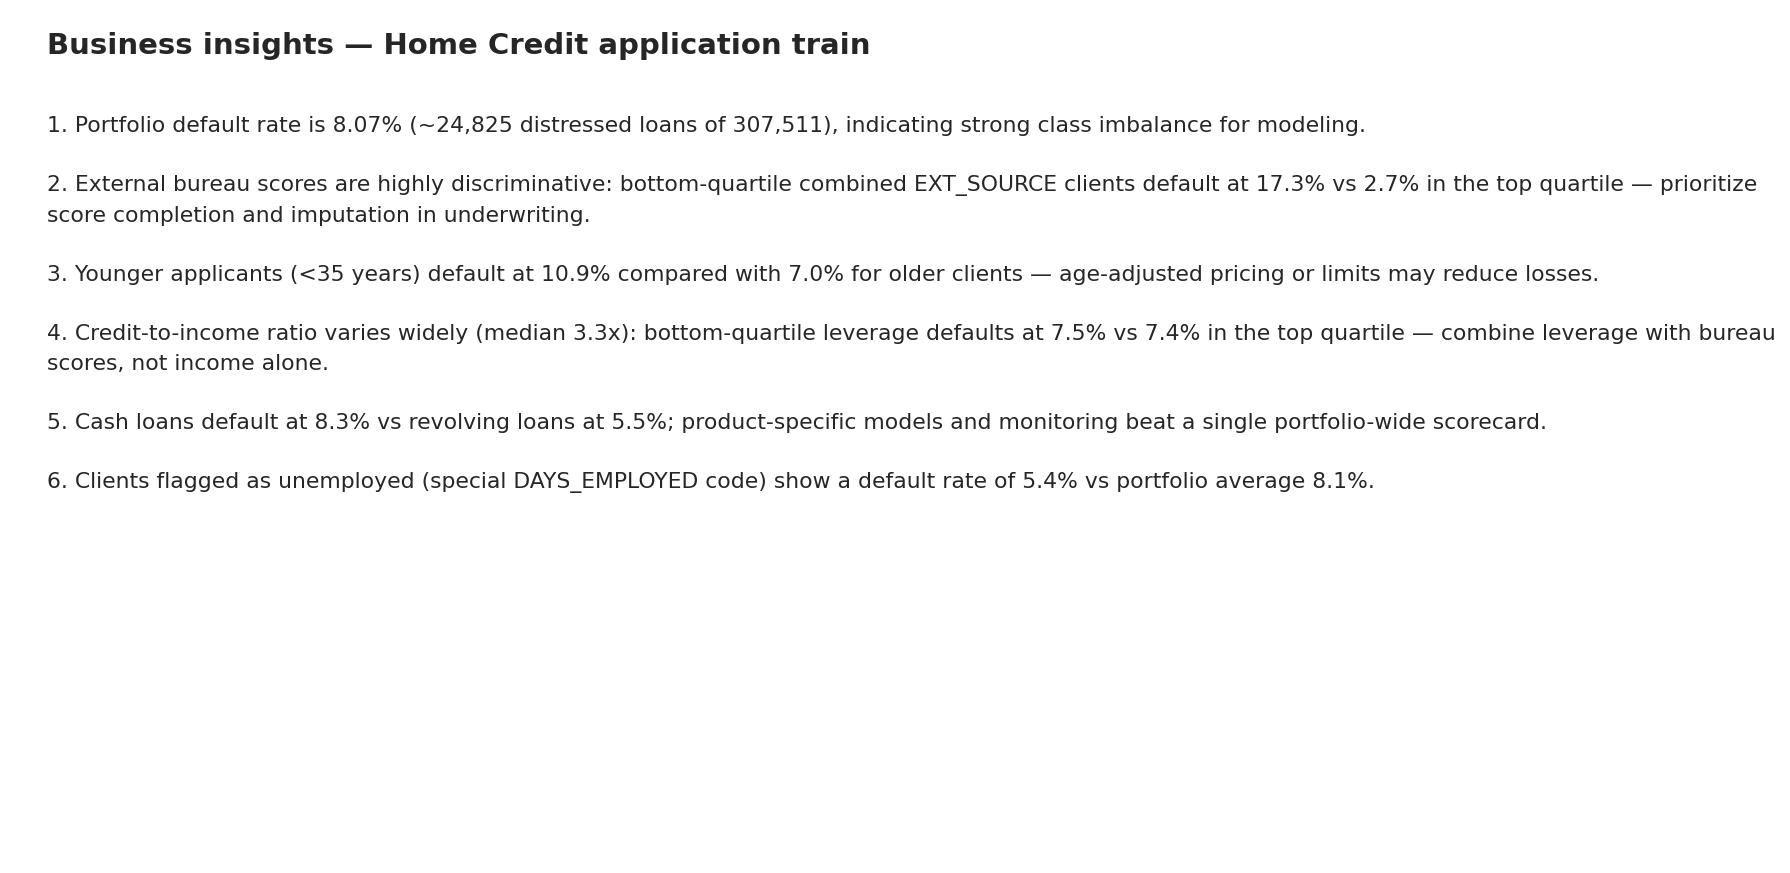

  Saved documents/eda/09_business_insights.png


,#,Insight
0,1,"Portfolio default rate is 8.07% (~24,825 distr..."
1,2,External bureau scores are highly discriminati...
2,3,Younger applicants (<35 years) default at 10.9...
3,4,Credit-to-income ratio varies widely (median 3...
4,5,Cash loans default at 8.3% vs revolving loans ...
5,6,Clients flagged as unemployed (special DAYS_EM...


In [9]:
insights = business_insights(df)
pd.DataFrame({"#": range(1, len(insights) + 1), "Insight": insights})

---

All figures are saved under `documents/eda/`. Re-run `python notebooks/eda.py` from the project root to regenerate exports without the notebook.